## 1. Data Loading

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load NHANES 2021-2023 modules
demo = pd.read_sas("DEMO_L.xpt")
dpq  = pd.read_sas("DPQ_L.xpt")
slq  = pd.read_sas("SLQ_L.xpt")
paq  = pd.read_sas("PAQ_L.xpt")
smq  = pd.read_sas("SMQ_L.xpt")

/opt/conda/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Outcome Variable: PHQ-9 Total Score

In [2]:
phq_items = ["DPQ010","DPQ020","DPQ030","DPQ040","DPQ050",
             "DPQ060","DPQ070","DPQ080","DPQ090"]

# Convert to numeric; handle SAS tiny-zero artifact
for c in phq_items:
    dpq[c] = pd.to_numeric(dpq[c], errors="coerce")
    dpq.loc[dpq[c] < 1e-10, c] = 0

# Replace refusal (7) and don't know (9) with NaN
for c in phq_items:
    dpq.loc[dpq[c].isin([7, 9]), c] = np.nan

# Keep only valid response values 0-3
for c in phq_items:
    dpq.loc[~dpq[c].isin([0, 1, 2, 3]), c] = np.nan

# Sum only when all 9 items are answered (min_count=9)
dpq["PHQ9_total"] = dpq[phq_items].sum(axis=1, min_count=9)

print("PHQ-9 descriptives:")
print(dpq["PHQ9_total"].describe())
print("Missing %:", dpq["PHQ9_total"].isna().mean().round(3))

PHQ-9 descriptives:
count    5455.000000
mean        4.133272
std         4.765574
min         0.000000
25%         1.000000
50%         2.000000
75%         6.000000
max        26.000000
Name: PHQ9_total, dtype: float64
Missing %: 0.139


## 3. Sociodemographic Predictors

In [3]:
demo = demo[["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "DMDEDUC2", "INDFMPIR"]]

# Merge demographics with PHQ-9. Keep only participants with valid PHQ-9
df = demo.merge(dpq[["SEQN", "PHQ9_total"]], on="SEQN", how="inner")
df = df[df["PHQ9_total"].notna()]

# Restrict to adults (older than 20 years)
df = df[df["RIDAGEYR"] >= 20]

# Poverty-income ratio: fix SAS tiny-zero, remove out of range values
df["INDFMPIR"] = pd.to_numeric(df["INDFMPIR"], errors="coerce")
df.loc[df["INDFMPIR"] < 1e-10, "INDFMPIR"] = 0
df.loc[(df["INDFMPIR"] < 0) | (df["INDFMPIR"] > 5), "INDFMPIR"] = np.nan

# Education: replace refusal (7) and don't know (9) with NaN
df["DMDEDUC2"] = pd.to_numeric(df["DMDEDUC2"], errors="coerce")
df.loc[df["DMDEDUC2"].isin([7, 9]), "DMDEDUC2"] = np.nan

print(f"Sample after demographic cleaning: {df.shape}")
print("Missingness:")
print(df[["INDFMPIR", "DMDEDUC2"]].isna().mean().round(3))

Sample after demographic cleaning: (5210, 7)
Missingness:
INDFMPIR    0.12
DMDEDUC2    0.00
dtype: float64


## 4. Behavioral Predictor: Sleep

In [4]:
sleep_df = slq[["SEQN", "SLD012"]].copy()
sleep_df["SLD012"] = pd.to_numeric(sleep_df["SLD012"], errors="coerce")

# Remove extreme special coded values used in NHANES
sleep_df.loc[sleep_df["SLD012"].isin([2, 14]), "SLD012"] = np.nan

# Binary: poor sleep = less than 7 hours per night
sleep_df["poor_sleep"] = (sleep_df["SLD012"] < 7).astype("Int64")
# Propagate NaN: if sleep_hours is NaN, poor_sleep should also be NaN
sleep_df.loc[sleep_df["SLD012"].isna(), "poor_sleep"] = np.nan

sleep_df = sleep_df.rename(columns={"SLD012": "sleep_hours"})

print("Sleep descriptives:")
print(sleep_df["sleep_hours"].describe())
print("Poor sleep (<7h) distribution:")
print(sleep_df["poor_sleep"].value_counts(dropna=False))
print("Missing %:", sleep_df["poor_sleep"].isna().mean().round(3))

Sleep descriptives:
count    8318.000000
mean        7.752404
std         1.526009
min         3.000000
25%         7.000000
50%         8.000000
75%         8.500000
max        13.500000
Name: sleep_hours, dtype: float64
Poor sleep (<7h) distribution:
poor_sleep
0       6615
1       1703
<NA>     183
Name: count, dtype: Int64
Missing %: 0.022


In [5]:
df_model = df.merge(sleep_df[["SEQN", "poor_sleep"]], on="SEQN", how="left")
print(f"Shape after sleep merge: {df_model.shape}")
print("poor_sleep missing %:", df_model["poor_sleep"].isna().mean().round(3))

Shape after sleep merge: (5210, 8)
poor_sleep missing %: 0.018


## 5. Behavioral Predictor: Smoking

In [6]:
df_smoking = smq[["SEQN", "SMQ040"]].copy()
df_smoking["SMQ040"] = pd.to_numeric(df_smoking["SMQ040"], errors="coerce")
df_smoking["SMQ040"] = df_smoking["SMQ040"].replace([7, 9], np.nan)

# Current smoker: 1 = every day, 2 = some days
df_smoking["current_smoker"] = df_smoking["SMQ040"].isin([1, 2]).astype(int)

df_model = df_model.merge(df_smoking[["SEQN", "current_smoker"]], on="SEQN", how="left")

# Participants not in SMQ (never smoked) coded as 0
df_model["current_smoker"] = df_model["current_smoker"].fillna(0)

print("Current smoker distribution:")
print(df_model["current_smoker"].value_counts(dropna=False))

Current smoker distribution:
current_smoker
0    4442
1     768
Name: count, dtype: int64


## 6. Behavioral Predictor: Physical Activity

In [7]:
# Select and convert relevant PA columns
pa_num_cols = ["PAD790Q", "PAD800", "PAD810Q", "PAD820"]
for col in pa_num_cols:
    paq[col] = pd.to_numeric(paq[col], errors="coerce")
    paq.loc[paq[col] < 1e-10, col] = np.nan

# Replace NHANES special codes (refuse / don't know)
for col in ["PAD790Q", "PAD800", "PAD810Q", "PAD820"]:
    paq[col] = paq[col].replace([7777, 9999], np.nan)

# Clean unit columns
paq["PAD790U"] = paq["PAD790U"].replace(b"", np.nan)
paq["PAD810U"] = paq["PAD810U"].replace(b"", np.nan)

# Convert activity frequency to weekly sessions
def convert_to_weekly(freq, unit):
    if pd.isna(freq) or pd.isna(unit):
        return 0  # missing is treated as no activity
    if unit == b'D':   return freq * 7
    elif unit == b'W': return freq
    elif unit == b'M': return freq / 4.33
    elif unit == b'Y': return freq / 52
    else: return 0

paq["mod_freq_week"] = paq.apply(lambda x: convert_to_weekly(x["PAD790Q"], x["PAD790U"]), axis=1)
paq["vig_freq_week"] = paq.apply(lambda x: convert_to_weekly(x["PAD810Q"], x["PAD810U"]), axis=1)

# Cap implausible frequencies (>3 sessions/day)
paq["mod_freq_week"] = paq["mod_freq_week"].clip(upper=21)
paq["vig_freq_week"] = paq["vig_freq_week"].clip(upper=21)

# Compute MET-weighted weekly minutes (vigorous counts double)
paq["PAD800"] = paq["PAD800"].fillna(0)
paq["PAD820"] = paq["PAD820"].fillna(0)
paq["mod_minutes_week"] = paq["mod_freq_week"] * paq["PAD800"]
paq["vig_minutes_week"]  = paq["vig_freq_week"]  * paq["PAD820"]
paq["total_pa_minutes"]  = (paq["mod_minutes_week"] + 2 * paq["vig_minutes_week"]).clip(upper=1680)

# Binary: low activity = below WHO 150 min/week threshold
paq["low_activity"] = (paq["total_pa_minutes"] < 150).astype(int)

print("Total PA minutes descriptives:")
print(paq["total_pa_minutes"].describe())
print("Low activity distribution:")
print(paq["low_activity"].value_counts(normalize=True).round(3))

Total PA minutes descriptives:
count    8153.000000
mean      313.711659
std       406.578997
min         0.000000
25%        27.713626
50%       170.000000
75%       420.000000
max      1680.000000
Name: total_pa_minutes, dtype: float64
Low activity distribution:
low_activity
0    0.522
1    0.478
Name: proportion, dtype: float64


In [8]:
df_model = df_model.merge(paq[["SEQN", "total_pa_minutes", "low_activity"]], on="SEQN", how="left")
print(f"Shape after PA merge: {df_model.shape}")
print("PA missingness:", df_model[["total_pa_minutes", "low_activity"]].isna().mean().round(3))

Shape after PA merge: (5210, 11)
PA missingness: total_pa_minutes    0.0
low_activity        0.0
dtype: float64


## 7. Final Analysis Dataset

In [9]:
# Keep only the variables entering the models. Drop rows with any missing value
common_vars = [
    "PHQ9_total",
    "poor_sleep",
    "low_activity",
    "current_smoker",
    "RIDAGEYR",
    "INDFMPIR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2"]

df_common = df_model[common_vars].dropna().copy()

# Ensure correct dtypes
df_common["poor_sleep"]     = df_common["poor_sleep"].astype(int)
df_common["low_activity"]   = df_common["low_activity"].astype(int)
df_common["current_smoker"] = df_common["current_smoker"].astype(int)

print(f"Final analytic sample: {df_common.shape}")
print("Descriptive statistics:")
print(df_common.describe().round(2))

Final analytic sample: (4505, 9)
Descriptive statistics:
       PHQ9_total  poor_sleep  low_activity  current_smoker  RIDAGEYR  \
count     4505.00     4505.00       4505.00         4505.00   4505.00   
mean         4.02        0.21          0.46            0.15     53.69   
std          4.67        0.40          0.50            0.36     16.93   
min          0.00        0.00          0.00            0.00     20.00   
25%          1.00        0.00          0.00            0.00     39.00   
50%          2.00        0.00          0.00            0.00     57.00   
75%          6.00        0.00          1.00            0.00     67.00   
max         26.00        1.00          1.00            1.00     80.00   

       INDFMPIR  RIAGENDR  RIDRETH3  DMDEDUC2  
count   4505.00   4505.00   4505.00   4505.00  
mean       3.04      1.55      3.29      3.96  
std        1.65      0.50      1.34      1.06  
min        0.00      1.00      1.00      1.00  
25%        1.56      1.00      3.00      3.00

## 8. Exploratory Data Analysis

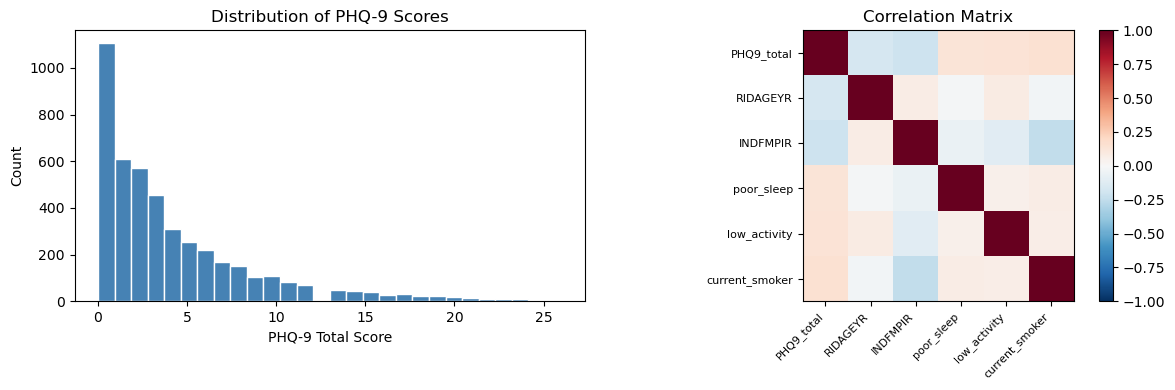

Correlation with PHQ-9:
INDFMPIR         -0.207
RIDAGEYR         -0.168
current_smoker    0.150
low_activity      0.137
poor_sleep        0.132
Name: PHQ9_total, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PHQ-9 distribution
axes[0].hist(df_common["PHQ9_total"], bins=28, edgecolor="white", color="steelblue")
axes[0].set_xlabel("PHQ-9 Total Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of PHQ-9 Scores")

# Correlation heatmap of continuous predictors
import matplotlib.colors as mcolors
cont_cols = ["PHQ9_total", "RIDAGEYR", "INDFMPIR",
             "poor_sleep", "low_activity", "current_smoker"]
corr = df_common[cont_cols].corr()
im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
axes[1].set_xticks(range(len(cont_cols)))
axes[1].set_yticks(range(len(cont_cols)))
axes[1].set_xticklabels(cont_cols, rotation=45, ha="right", fontsize=8)
axes[1].set_yticklabels(cont_cols, fontsize=8)
axes[1].set_title("Correlation Matrix")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()
print("Correlation with PHQ-9:")
print(corr["PHQ9_total"].drop("PHQ9_total").sort_values(key=abs, ascending=False).round(3))

## 9. Multicollinearity Check (VIF)

In [11]:
X_vif = df_common[[
    "poor_sleep",
    "low_activity",
    "current_smoker",
    "RIDAGEYR",
    "INDFMPIR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2"]].copy()

for col in ["RIAGENDR", "RIDRETH3", "DMDEDUC2"]:
    X_vif[col] = X_vif[col].astype("category")

X_vif = pd.get_dummies(X_vif, drop_first=True).astype(float)

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})

print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

       feature       VIF
  RIDRETH3_3.0 11.557968
      RIDAGEYR  9.694512
  DMDEDUC2_5.0  9.464930
  DMDEDUC2_4.0  6.775239
      INDFMPIR  6.321771
  DMDEDUC2_3.0  4.562250
  RIDRETH3_4.0  2.686126
  RIAGENDR_2.0  2.247831
  RIDRETH3_2.0  2.215601
  DMDEDUC2_2.0  2.100821
  RIDRETH3_7.0  2.019131
  low_activity  1.926509
  RIDRETH3_6.0  1.718106
current_smoker  1.303265
    poor_sleep  1.281846


## 10. Regression Models

In [12]:
y = df_common["PHQ9_total"].astype(float)

# Helper to dummy-encode and add constant
def prep_X(df_subset):
    X = df_subset.copy()
    for col in ["RIAGENDR", "RIDRETH3", "DMDEDUC2"]:
        if col in X.columns:
            X[col] = X[col].astype("category")
    X = pd.get_dummies(X, drop_first=True).astype(float)
    return sm.add_constant(X)

# Model 1: Demographic
X_demo = prep_X(df_common[["RIDAGEYR", "INDFMPIR", "RIAGENDR", "RIDRETH3", "DMDEDUC2"]])
model_demo = sm.OLS(y, X_demo).fit()

# Model 2: Behavioral 
X_behav = prep_X(df_common[["poor_sleep", "low_activity", "current_smoker"]])
model_behav = sm.OLS(y, X_behav).fit()

# Model 3: Combined 
X_combined = prep_X(df_common[[
    "poor_sleep", "low_activity", "current_smoker",
    "RIDAGEYR", "INDFMPIR", "RIAGENDR", "RIDRETH3", "DMDEDUC2"]])
model_combined = sm.OLS(y, X_combined).fit()

print("=" * 60)
print("MODEL 1: Demographic")
print(model_demo.summary())

MODEL 1: Demographic
                            OLS Regression Results                            
Dep. Variable:             PHQ9_total   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     33.88
Date:                Mon, 18 May 2026   Prob (F-statistic):           5.95e-76
Time:                        14:24:24   Log-Likelihood:                -13140.
No. Observations:                4505   AIC:                         2.631e+04
Df Residuals:                    4492   BIC:                         2.639e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.3239    

In [13]:
print("=" * 60)
print("MODEL 2: Behavioral")
print(model_behav.summary())

MODEL 2: Behavioral
                            OLS Regression Results                            
Dep. Variable:             PHQ9_total   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     82.09
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.05e-51
Time:                        14:24:25   Log-Likelihood:                -13215.
No. Observations:                4505   AIC:                         2.644e+04
Df Residuals:                    4501   BIC:                         2.646e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.957

In [14]:
print("=" * 60)
print("MODEL 3: Combined")
print(model_combined.summary())

MODEL 3: Combined
                            OLS Regression Results                            
Dep. Variable:             PHQ9_total   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     40.38
Date:                Mon, 18 May 2026   Prob (F-statistic):          1.34e-111
Time:                        14:24:25   Log-Likelihood:                -13050.
No. Observations:                4505   AIC:                         2.613e+04
Df Residuals:                    4489   BIC:                         2.623e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              6.1585 

## 11. Incremental Predictive Value

In [15]:
r2_demo     = model_demo.rsquared_adj
r2_behav    = model_behav.rsquared_adj
r2_combined = model_combined.rsquared_adj
delta_r2    = r2_combined - r2_demo

print(f"Adjusted R²  –  Demographic model : {r2_demo:.4f}")
print(f"Adjusted R²  –  Behavioral model  : {r2_behav:.4f}")
print(f"Adjusted R²  –  Combined model    : {r2_combined:.4f}")
print(f"ΔR² (combined – demographic)      : {delta_r2:.4f}")

# Formal F-test to test if adding behavioral predictors do significantly improve fit
# Uses the restricted (demographic) and unrestricted (combined) models
n   = len(y)
k_r = model_demo.df_model        # df of restricted model
k_u = model_combined.df_model    # df of unrestricted model

rss_r = model_demo.ssr
rss_u = model_combined.ssr
df_num = k_u - k_r               # number of added predictors
df_den = n - k_u - 1

F_stat = ((rss_r - rss_u) / df_num) / (rss_u / df_den)
from scipy import stats
p_value = stats.f.sf(F_stat, df_num, df_den)

print(f"F-test for incremental fit of behavioral predictors:")
print(f"  F({int(df_num)}, {int(df_den)}) = {F_stat:.3f},  p = {p_value:.4f}")
if p_value < 0.05:
    print("  → Behavioral predictors provide statistically significant incremental fit.")
else:
    print("  → Behavioral predictors do NOT provide significant incremental fit.")

Adjusted R²  –  Demographic model : 0.0805
Adjusted R²  –  Behavioral model  : 0.0512
Adjusted R²  –  Combined model    : 0.1160
ΔR² (combined – demographic)      : 0.0354
F-test for incremental fit of behavioral predictors:
  F(3, 4489) = 60.968,  p = 0.0000
  → Behavioral predictors provide statistically significant incremental fit.


## 12. Cross-Validated Performance (All Three Models)

In [16]:
def cv_results(X_sm, y, label, kf):
    
    # Drop the statsmodels constant column. sklearn adds its own intercept
    X_sk = X_sm.drop(columns=["const"]).values
    model_sk = LinearRegression()
    rmse_scorer = make_scorer(root_mean_squared_error)
    r2_cv   = cross_val_score(model_sk, X_sk, y, cv=kf, scoring="r2")
    rmse_cv = cross_val_score(model_sk, X_sk, y, cv=kf, scoring=rmse_scorer)
    print(f"{label}")
    print(f"  CV R²   : {r2_cv.round(4)}  → mean = {r2_cv.mean():.4f}  (SD={r2_cv.std():.4f})")
    print(f"  CV RMSE : {rmse_cv.round(4)}  → mean = {rmse_cv.mean():.4f}  (SD={rmse_cv.std():.4f})")
    print()
    return r2_cv.mean(), rmse_cv.mean()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_demo_cv,     rmse_demo_cv     = cv_results(X_demo,     y, "Model 1: Demographic", kf)
r2_behav_cv,    rmse_behav_cv    = cv_results(X_behav,    y, "Model 2: Behavioral",  kf)
r2_combined_cv, rmse_combined_cv = cv_results(X_combined, y, "Model 3: Combined",    kf)

print(f"Cross-validated ΔR² (combined – demographic): {r2_combined_cv - r2_demo_cv:.4f}")

Model 1: Demographic
  CV R²   : [0.1006 0.0411 0.0581 0.0994 0.0661]  → mean = 0.0731  (SD=0.0234)
  CV RMSE : [4.4697 4.3843 4.533  4.6933 4.3478]  → mean = 4.4856  (SD=0.1224)

Model 2: Behavioral
  CV R²   : [0.0532 0.0482 0.0228 0.0463 0.0614]  → mean = 0.0464  (SD=0.0129)
  CV RMSE : [4.5859 4.3681 4.6173 4.8296 4.3588]  → mean = 4.5519  (SD=0.1753)

Model 3: Combined
  CV R²   : [0.1338 0.0867 0.0787 0.1284 0.1121]  → mean = 0.1079  (SD=0.0219)
  CV RMSE : [4.3865 4.2787 4.4832 4.617  4.2395]  → mean = 4.4010  (SD=0.1376)

Cross-validated ΔR² (combined – demographic): 0.0349


## 13. Ridge Regression – Relative Feature Importance

In [17]:
X_ridge = X_combined.drop(columns=["const"])
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_ridge)

ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "feature"    : X_ridge.columns,
    "ridge_coef" : ridge.coef_}).sort_values("ridge_coef", key=abs, ascending=False)

print("Standardised Ridge coefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

Standardised Ridge coefficients (sorted by absolute magnitude):
       feature  ridge_coef
      RIDAGEYR   -0.810523
      INDFMPIR   -0.682061
    poor_sleep    0.539211
  low_activity    0.529694
current_smoker    0.434521
  RIAGENDR_2.0    0.423085
  RIDRETH3_3.0    0.392999
  RIDRETH3_7.0    0.277253
  DMDEDUC2_5.0   -0.217918
  DMDEDUC2_3.0   -0.190738
  RIDRETH3_2.0    0.169113
  RIDRETH3_6.0   -0.093174
  DMDEDUC2_2.0   -0.078640
  DMDEDUC2_4.0   -0.074808
  RIDRETH3_4.0    0.001593


## 14. Robustness Check: Negative Binomial Regression

In [18]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# X_nb: combined predictor set (same as OLS combined, minus constant)
X_nb = X_combined.drop(columns=["const"]).copy()

# y_int: PHQ-9 as non-negative integer (required for count models)
y_int = y.astype(int)

# Standardise only continuous predictors to help optimizer converge
scaler_nb = StandardScaler()
X_nb_scaled = X_nb.copy()
cont_cols = ["RIDAGEYR", "INDFMPIR"]
X_nb_scaled[cont_cols] = scaler_nb.fit_transform(X_nb[cont_cols])

# Fit negative binomial regression
model_nb = sm.NegativeBinomial(
    y_int,
    sm.add_constant(X_nb_scaled)).fit(
    method="bfgs",
    maxiter=500,
    disp=False)

print("Converged:", model_nb.mle_retvals["converged"])
print(model_nb.summary())

Converged: True
                     NegativeBinomial Regression Results                      
Dep. Variable:             PHQ9_total   No. Observations:                 4505
Model:               NegativeBinomial   Df Residuals:                     4489
Method:                           MLE   Df Model:                           15
Date:                Mon, 18 May 2026   Pseudo R-squ.:                 0.02341
Time:                        14:24:26   Log-Likelihood:                -11001.
converged:                       True   LL-Null:                       -11264.
Covariance Type:            nonrobust   LLR p-value:                9.321e-103
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.8891      0.115      7.747      0.000       0.664       1.114
poor_sleep         0.3319      0.042      7.914      0.000       0.250       0.414
low_activity       0

In [19]:
# Compare OLS vs NB coefficients on behavioral predictors
# NB gives log-IRR (incidence rate ratios). Exponentiate for interpretation

import numpy as np

behav_vars = ["poor_sleep", "low_activity", "current_smoker"]

print("Robustness check: OLS vs Negative Binomial on behavioral predictors")
print("-" * 65)
print(f"{'Predictor':<20} {'OLS coef':>10} {'NB coef':>10} {'NB IRR':>10} {'NB p':>8}")
print("-" * 65)

for var in behav_vars:
    ols_coef = model_combined.params[var]
    nb_coef  = model_nb.params[var]
    nb_irr   = np.exp(nb_coef)
    nb_p     = model_nb.pvalues[var]
    print(f"{var:<20} {ols_coef:>10.3f} {nb_coef:>10.3f} {nb_irr:>10.3f} {nb_p:>8.4f}")

print("-" * 65)
print("\nIf all three remain significant and in the same direction,")
print("OLS conclusions are considered robust to distributional assumptions.")

Robustness check: OLS vs Negative Binomial on behavioral predictors
-----------------------------------------------------------------
Predictor              OLS coef    NB coef     NB IRR     NB p
-----------------------------------------------------------------
poor_sleep                1.334      0.332      1.394   0.0000
low_activity              1.063      0.314      1.369   0.0000
current_smoker            1.221      0.248      1.281   0.0000
-----------------------------------------------------------------

If all three remain significant and in the same direction,
OLS conclusions are considered robust to distributional assumptions.


## 15. Random Forest Regression

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, root_mean_squared_error

# prepare sklearn-ready matrices from statsmodels X
def sm_to_sk(X_sm):
    return X_sm.drop(columns=["const"]).values

def get_feature_names(X_sm):
    return list(X_sm.drop(columns=["const"]).columns)

# Random forest CV across all three predictor sets
kf_rf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scorer = make_scorer(root_mean_squared_error)

rf_params = dict(n_estimators=500, max_features="sqrt",
                 min_samples_leaf=5, random_state=42, n_jobs=-1)

results_rf = {}
for label, X_sm in [("Demographic", X_demo),
                    ("Behavioral",  X_behav),
                    ("Combined",    X_combined)]:
    rf  = RandomForestRegressor(**rf_params)
    Xsk = sm_to_sk(X_sm)
    r2   = cross_val_score(rf, Xsk, y, cv=kf_rf, scoring="r2")
    rmse = cross_val_score(rf, Xsk, y, cv=kf_rf, scoring=rmse_scorer)
    results_rf[label] = {"r2_mean": r2.mean(), "r2_sd": r2.std(),
                         "rmse_mean": rmse.mean(), "rmse_sd": rmse.std()}
    print(f"RF – {label} model")
    print(f"  CV R²   : {r2.round(4)}  → mean={r2.mean():.4f}  (SD={r2.std():.4f})")
    print(f"  CV RMSE : {rmse.round(4)}  → mean={rmse.mean():.4f}  (SD={rmse.std():.4f})")
    print()

RF – Demographic model
  CV R²   : [0.0702 0.0262 0.0391 0.0926 0.0311]  → mean=0.0518  (SD=0.0255)
  CV RMSE : [4.5447 4.4183 4.5785 4.7111 4.4286]  → mean=4.5362  (SD=0.1076)

RF – Behavioral model
  CV R²   : [0.0598 0.0423 0.027  0.0455 0.0632]  → mean=0.0475  (SD=0.0130)
  CV RMSE : [4.57   4.3815 4.6073 4.8317 4.3546]  → mean=4.5490  (SD=0.1730)

RF – Combined model
  CV R²   : [0.1172 0.0739 0.0892 0.1263 0.0898]  → mean=0.0993  (SD=0.0194)
  CV RMSE : [4.4281 4.3086 4.4577 4.6226 4.2923]  → mean=4.4219  (SD=0.1193)



In [21]:
# Summary comparison table of OLS vs RF 
print("Model performance summary (cross-validated)")
print("-" * 70)
print(f"{'Model':<25} {'OLS R²':>8} {'RF R²':>8} {'OLS RMSE':>10} {'RF RMSE':>10}")
print("-" * 70)

ols_r2   = {"Demographic": r2_demo_cv,     "Behavioral": r2_behav_cv,    "Combined": r2_combined_cv}
ols_rmse = {"Demographic": rmse_demo_cv,   "Behavioral": rmse_behav_cv,  "Combined": rmse_combined_cv}

for label in ["Demographic", "Behavioral", "Combined"]:
    print(f"{label:<25} {ols_r2[label]:>8.4f} {results_rf[label]['r2_mean']:>8.4f} " f"{ols_rmse[label]:>10.4f} {results_rf[label]['rmse_mean']:>10.4f}")
print("-" * 70)
delta_ols = r2_combined_cv - r2_demo_cv
delta_rf  = results_rf["Combined"]["r2_mean"] - results_rf["Demographic"]["r2_mean"]
print(f"\nIncremental ΔR² (combined – demographic):  OLS = {delta_ols:.4f}  |  RF = {delta_rf:.4f}")
print("(A larger RF ΔR² suggests non-linear relationships carry additional predictive value.)")

Model performance summary (cross-validated)
----------------------------------------------------------------------
Model                       OLS R²    RF R²   OLS RMSE    RF RMSE
----------------------------------------------------------------------
Demographic                 0.0731   0.0518     4.4856     4.5362
Behavioral                  0.0464   0.0475     4.5519     4.5490
Combined                    0.1079   0.0993     4.4010     4.4219
----------------------------------------------------------------------

Incremental ΔR² (combined – demographic):  OLS = 0.0349  |  RF = 0.0475
(A larger RF ΔR² suggests non-linear relationships carry additional predictive value.)


In [22]:
# Feature importance from RF trained on full combined set
rf_full = RandomForestRegressor(**rf_params)
X_comb_sk  = sm_to_sk(X_combined)
feat_names = get_feature_names(X_combined)

rf_full.fit(X_comb_sk, y)

importance_df = pd.DataFrame({
    "feature"   : feat_names,
    "importance": rf_full.feature_importances_}).sort_values("importance", ascending=False).reset_index(drop=True)

# Tag each feature as demographic or behavioral for colour coding
behav_feats = {"poor_sleep", "low_activity", "current_smoker"}
importance_df["domain"] = importance_df["feature"].apply(
    lambda f: "Behavioral" if any(b in f for b in behav_feats) else "Demographic")

print("Feature importances (RF, combined model, trained on full sample):")
print(importance_df[["feature", "importance", "domain"]].to_string(index=False))

Feature importances (RF, combined model, trained on full sample):
       feature  importance      domain
      INDFMPIR    0.309642 Demographic
      RIDAGEYR    0.295932 Demographic
  low_activity    0.065863  Behavioral
    poor_sleep    0.060187  Behavioral
current_smoker    0.055230  Behavioral
  RIAGENDR_2.0    0.051138 Demographic
  RIDRETH3_3.0    0.028977 Demographic
  DMDEDUC2_5.0    0.026809 Demographic
  DMDEDUC2_4.0    0.023376 Demographic
  DMDEDUC2_3.0    0.019665 Demographic
  RIDRETH3_4.0    0.014586 Demographic
  RIDRETH3_2.0    0.014514 Demographic
  RIDRETH3_7.0    0.013764 Demographic
  DMDEDUC2_2.0    0.012386 Demographic
  RIDRETH3_6.0    0.007931 Demographic


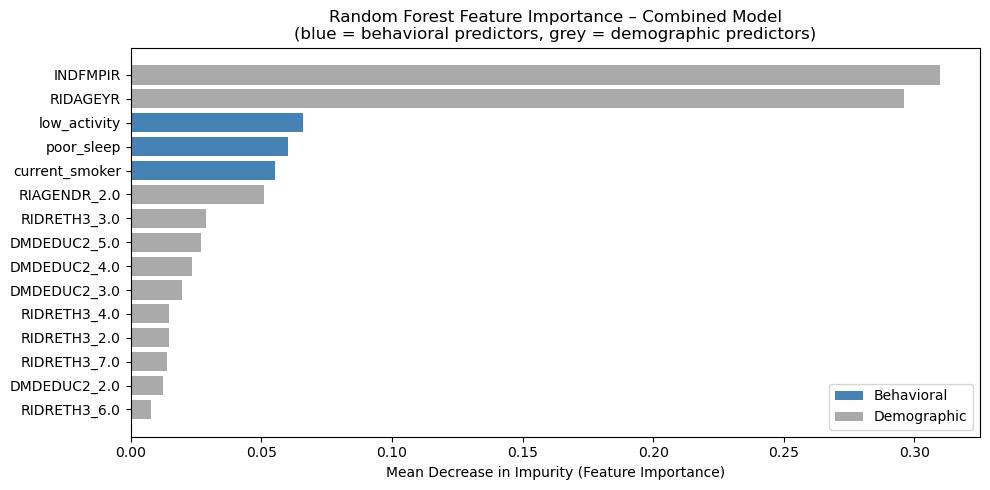

In [23]:
# Feature importance plot
colors = ["steelblue" if d == "Behavioral" else "#aaaaaa"
          for d in importance_df["domain"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importance_df["feature"][::-1],
               importance_df["importance"][::-1],
               color=colors[::-1])
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
ax.set_title("Random Forest Feature Importance – Combined Model\n" 
             "(blue = behavioral predictors, grey = demographic predictors)")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", label="Behavioral"),
                   Patch(facecolor="#aaaaaa",   label="Demographic")]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

## 16 Counterfactual Intervention Simulations

In [24]:
sim_df = df_common.copy()

def predict_from_df(df_sim, model):    
    X = df_sim.drop(columns=["PHQ9_total"], errors="ignore")
    for col in ["RIAGENDR", "RIDRETH3", "DMDEDUC2"]:
        if col in X.columns:
            X[col] = X[col].astype("category")
    X = pd.get_dummies(X, drop_first=True).astype(float)
    X = sm.add_constant(X)
    X = X.reindex(columns=model.model.exog_names, fill_value=0)
    return model.predict(X)

sim_df["baseline_pred"] = predict_from_df(sim_df, model_combined)

# PA intervention: make inactive participants active 
sim_pa = sim_df.copy()
sim_pa.loc[sim_pa["low_activity"] == 1, "low_activity"] = 0
sim_pa["pred_pa"] = predict_from_df(sim_pa.drop(columns=["baseline_pred"]), model_combined)

# Smoking cessation
sim_smoke = sim_df.copy()
sim_smoke.loc[sim_smoke["current_smoker"] == 1, "current_smoker"] = 0
sim_smoke["pred_smoke"] = predict_from_df(sim_smoke.drop(columns=["baseline_pred"]), model_combined)

# Sleep improvement: poor sleepers gain adequate sleep
sim_sleep = sim_df.copy()
sim_sleep.loc[sim_sleep["poor_sleep"] == 1, "poor_sleep"] = 0
sim_sleep["pred_sleep"] = predict_from_df(sim_sleep.drop(columns=["baseline_pred"]), model_combined)


# Report effects among affected subgroups only 
effects = { "PA" : ( sim_pa.loc[sim_df["low_activity"]   == 1, "pred_pa"]    - sim_df.loc[sim_df["low_activity"]   == 1, "baseline_pred"]).mean(),
           "Smoking"  : ( sim_smoke.loc[sim_df["current_smoker"] == 1, "pred_smoke"] - sim_df.loc[sim_df["current_smoker"] == 1, "baseline_pred"]).mean(),
           "Adequate Sleep": ( sim_sleep.loc[sim_df["poor_sleep"]   == 1, "pred_sleep"] - sim_df.loc[sim_df["poor_sleep"]   == 1, "baseline_pred"]).mean()}

print("Predicted change in PHQ-9 score per intervention:")
for k, v in effects.items():
    print(f"  {k.replace(chr(10), '  ')} : {v:+.3f}")

Predicted change in PHQ-9 score per intervention:
  PA : -1.063
  Smoking : -1.221
  Adequate Sleep : -1.334


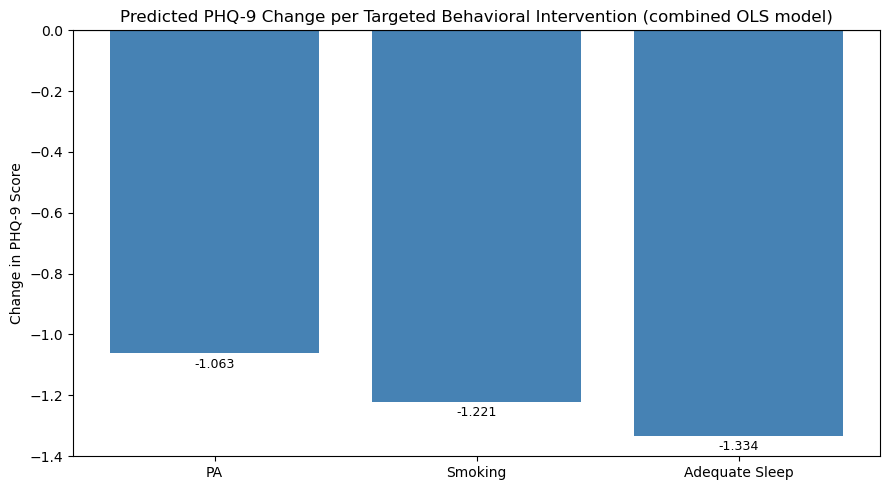

In [25]:
effects_df = pd.DataFrame({
    "Intervention"  : list(effects.keys()),
    "Effect_on_PHQ9": list(effects.values())})

colors = ["steelblue" if v < 0 else "tomato" for v in effects_df["Effect_on_PHQ9"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(effects_df["Intervention"], effects_df["Effect_on_PHQ9"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Change in PHQ-9 Score")
ax.set_title("Predicted PHQ-9 Change per Targeted Behavioral Intervention (combined OLS model)")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("intervention_effects.png", dpi=150)
plt.show()

In [26]:
from scipy import stats

phq9 = df_common["PHQ9_total"]

skewness = phq9.skew()
kurt = phq9.kurtosis()  # this gives excess kurtosis 

print(f"PHQ-9 Skewness: {skewness:.4f}")
print(f"PHQ-9 Excess Kurtosis: {kurt:.4f}")

# Also check OLS residuals skew/kurtosis
residuals = model_combined.resid
print(f"\nOLS Combined Model Residuals:")
print(f"  Skewness : {residuals.skew():.4f}")
print(f"  Kurtosis : {residuals.kurtosis():.4f}")

PHQ-9 Skewness: 1.6910
PHQ-9 Excess Kurtosis: 2.9067

OLS Combined Model Residuals:
  Skewness : 1.5175
  Kurtosis : 2.7878
